# 03 — First Analytical Pass

**Week 2 exploratory analysis on the enriched data.**

Goal: surface candidate findings for Week 3's Tableau dashboard and Medium article. Each chart is a question, not a conclusion — we'll polish/confirm in Week 3.

Working ideas going in (from the Week 2 plan):
1. Monthly median price trends for top 10 areas — which areas decoupled from the broader market?
2. YoY heatmap — which year-area combos saw the largest moves?
3. Off-plan vs ready price gap — what's the temporal pattern, especially through cycles?
4. Supply pipeline — where is supply concentrated and how does it correlate with prices?

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')

from src import config, db
print('db path:', config.DB_PATH.name)

db path: real_estate.db


## 1. Monthly median price/sqft for top 10 areas (Units, Sales only)

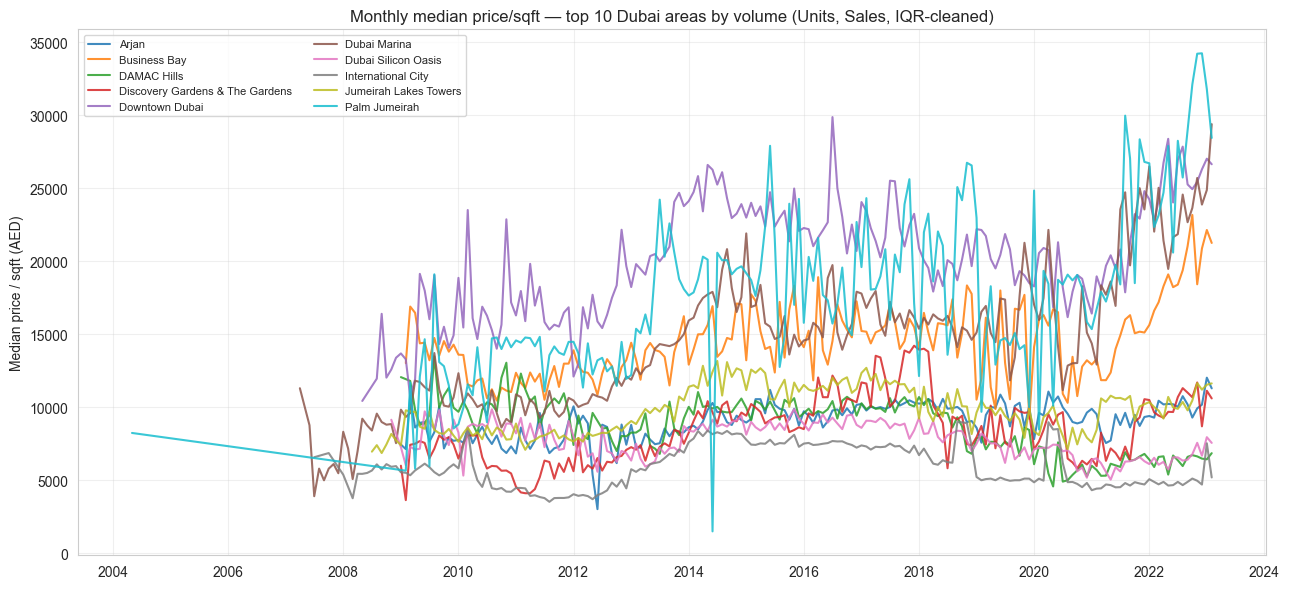

In [2]:
with db.connect() as conn:
    # Top 10 areas by transaction volume (Units only) for a focused chart
    top10 = pd.read_sql(
        """SELECT COALESCE(a.display_name, a.area_name) AS area, a.area_id, COUNT(*) AS n
           FROM transactions t JOIN areas a ON a.area_id = t.area_id
           WHERE t.txn_type='Sales' AND t.iqr_flag=0 AND t.property_type='Unit'
           GROUP BY a.area_id ORDER BY n DESC LIMIT 10""",
        conn,
    )
    monthly = pd.read_sql(
        f"""SELECT m.area_id, m.year_month, m.median_price_per_sqft, m.txn_count
            FROM v_monthly_area_medians m
            WHERE m.property_type='Unit' AND m.area_id IN ({','.join(map(str, top10['area_id']))})
              AND m.txn_count >= 10""",
        conn,
    )
monthly = monthly.merge(top10[['area_id', 'area']], on='area_id')
monthly['year_month'] = pd.to_datetime(monthly['year_month'])

fig, ax = plt.subplots(figsize=(13, 6))
for area, grp in monthly.groupby('area'):
    grp = grp.sort_values('year_month')
    ax.plot(grp['year_month'], grp['median_price_per_sqft'], label=area, alpha=0.85)
ax.set_ylabel('Median price / sqft (AED)'); ax.set_xlabel('')
ax.set_title('Monthly median price/sqft — top 10 Dubai areas by volume (Units, Sales, IQR-cleaned)')
ax.legend(loc='upper left', fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Read the chart:** look for areas whose lines move *independently* of the broader pack. Those are candidates for "decoupled" findings.

## 2. YoY heatmap (areas × years) — Units only

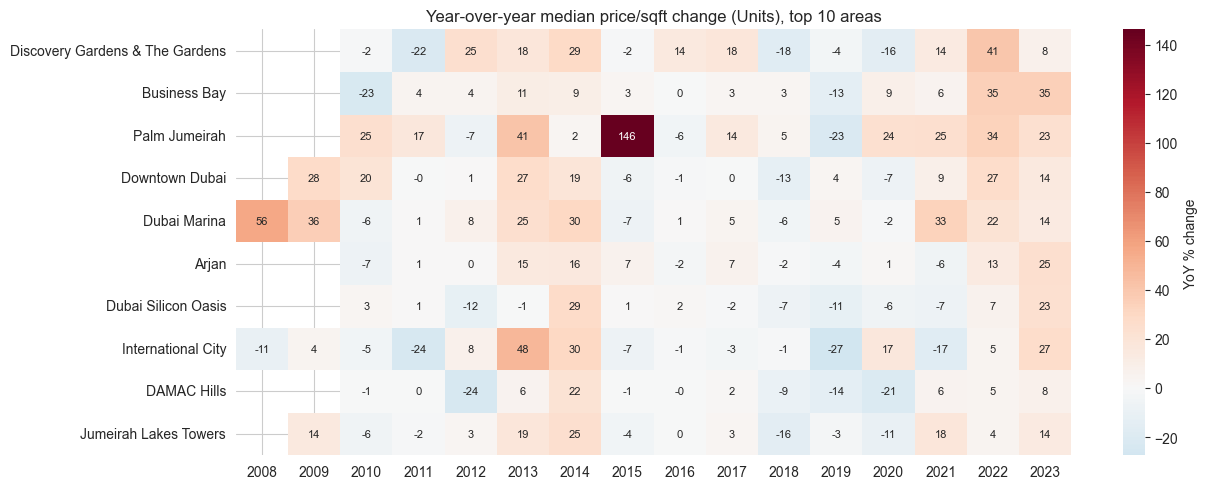

In [3]:
with db.connect() as conn:
    yoy = pd.read_sql(
        f"""SELECT COALESCE(a.display_name, a.area_name) AS area,
                   substr(y.year_month, 1, 4) AS year,
                   AVG(y.yoy_pct_change) AS yoy_pct
            FROM v_yoy_change_by_area_proptype y
            JOIN areas a ON a.area_id = y.area_id
            WHERE y.property_type='Unit'
              AND y.area_id IN ({','.join(map(str, top10['area_id']))})
              AND y.current_txn_count >= 30 AND y.prior_year_txn_count >= 30
            GROUP BY area, year""",
        conn,
    )
pivot = yoy.pivot(index='area', columns='year', values='yoy_pct')
# Order rows by 2022 YoY to highlight strongest current movers at top
if '2022' in pivot.columns:
    pivot = pivot.loc[pivot['2022'].sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            cbar_kws={'label': 'YoY % change'}, ax=ax, annot_kws={'size': 8})
ax.set_title('Year-over-year median price/sqft change (Units), top 10 areas')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

**Read the heatmap:** look for the **2008 GFC red band**, the **2014–16 cooling** after the mortgage cap, the **2020 COVID dip** (negative blue), and the **2021–22 boom**. Vertical comparisons show which areas led/lagged each cycle.

## 3. Off-plan vs ready price gap — Business Bay deep dive

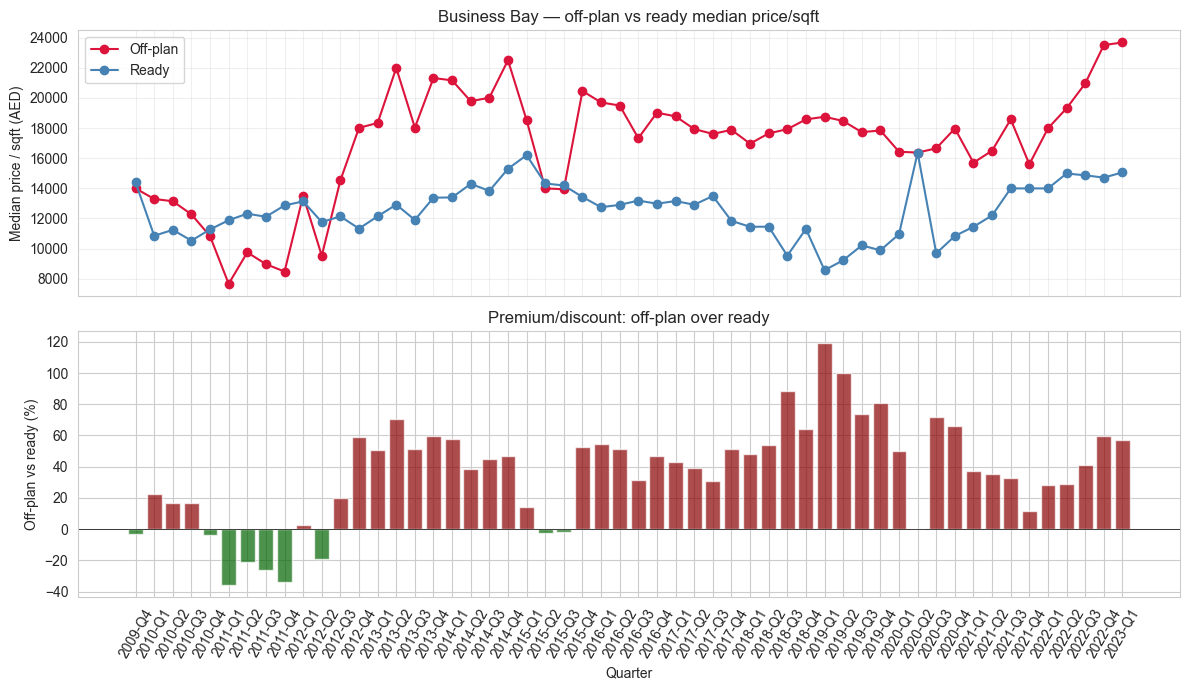

Quarters where off-plan traded above ready: 45 / 54
Median gap %: 41.9%


In [4]:
# Focus on one area at a time — Business Bay is the canonical case
with db.connect() as conn:
    gap = pd.read_sql(
        """SELECT g.year_quarter, g.median_pps_offplan, g.median_pps_ready,
                  g.offplan_txn_count, g.ready_txn_count
           FROM v_offplan_vs_ready_gap g JOIN areas a ON a.area_id = g.area_id
           WHERE a.area_name = 'Business Bay'
             AND g.offplan_txn_count >= 20 AND g.ready_txn_count >= 20
           ORDER BY g.year_quarter""",
        conn,
    )
gap['gap_pct'] = 100 * (gap['median_pps_offplan'] - gap['median_pps_ready']) / gap['median_pps_ready']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(gap['year_quarter'], gap['median_pps_offplan'], marker='o', label='Off-plan', color='crimson')
ax1.plot(gap['year_quarter'], gap['median_pps_ready'],   marker='o', label='Ready',     color='steelblue')
ax1.set_ylabel('Median price / sqft (AED)')
ax1.set_title('Business Bay — off-plan vs ready median price/sqft')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.bar(gap['year_quarter'], gap['gap_pct'],
        color=['darkred' if x > 0 else 'darkgreen' for x in gap['gap_pct']], alpha=0.7)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('Off-plan vs ready (%)'); ax2.set_xlabel('Quarter')
ax2.set_title('Premium/discount: off-plan over ready')
ax2.tick_params(axis='x', rotation=60)
plt.tight_layout(); plt.show()

print('Quarters where off-plan traded above ready:', (gap['gap_pct'] > 0).sum(), '/', len(gap))
print('Median gap %:', f'{gap["gap_pct"].median():.1f}%')

**The Business Bay off-plan inversion is real and persistent.** Conventional wisdom says off-plan trades at a discount to compensate for completion/handover risk; Business Bay shows the opposite. Hypothesis: new launches concentrate in *premium positions* (Burj-facing towers, prime Damac launches) while ready stock includes the older mid-tier supply. **Worth a paragraph in the Medium article.**

## 4. Off-plan share over time (Dubai-wide)

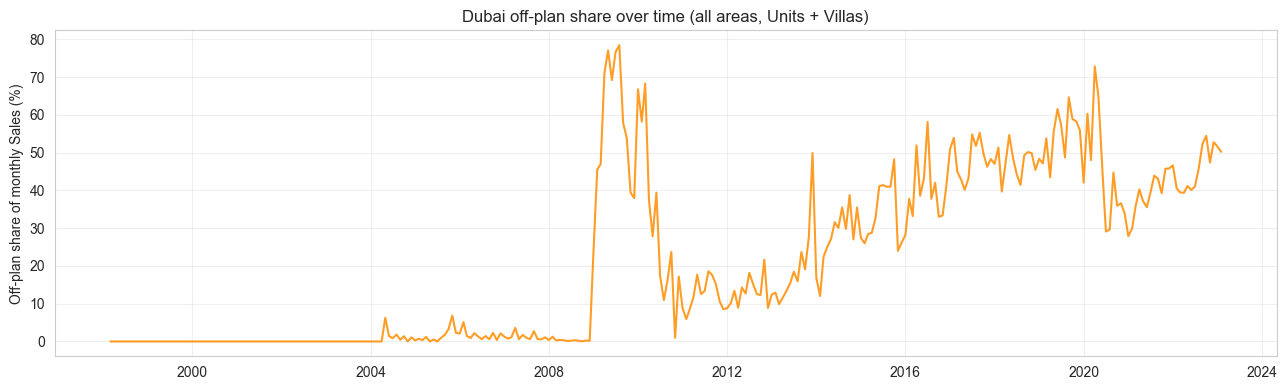

In [5]:
with db.connect() as conn:
    share = pd.read_sql(
        """SELECT substr(txn_date, 1, 7) AS year_month,
                  AVG(CAST(is_offplan AS REAL)) AS offplan_share,
                  COUNT(*) AS n
           FROM transactions
           WHERE txn_type='Sales' AND iqr_flag=0 AND is_offplan IS NOT NULL
           GROUP BY 1 HAVING n >= 50 ORDER BY 1""",
        conn,
    )
share['year_month'] = pd.to_datetime(share['year_month'])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(share['year_month'], share['offplan_share'] * 100, color='darkorange', alpha=0.85)
ax.set_ylabel('Off-plan share of monthly Sales (%)')
ax.set_title('Dubai off-plan share over time (all areas, Units + Villas)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**The off-plan share is a market-sentiment gauge.** Spikes = launch waves / bullish sentiment. Troughs = post-correction risk aversion (e.g. 2009 collapse, 2018–19 sluggishness). Watch for the 2021–22 spike that maps to the post-COVID developer launch wave.

## 5. Supply pipeline — Meydan as supply leader

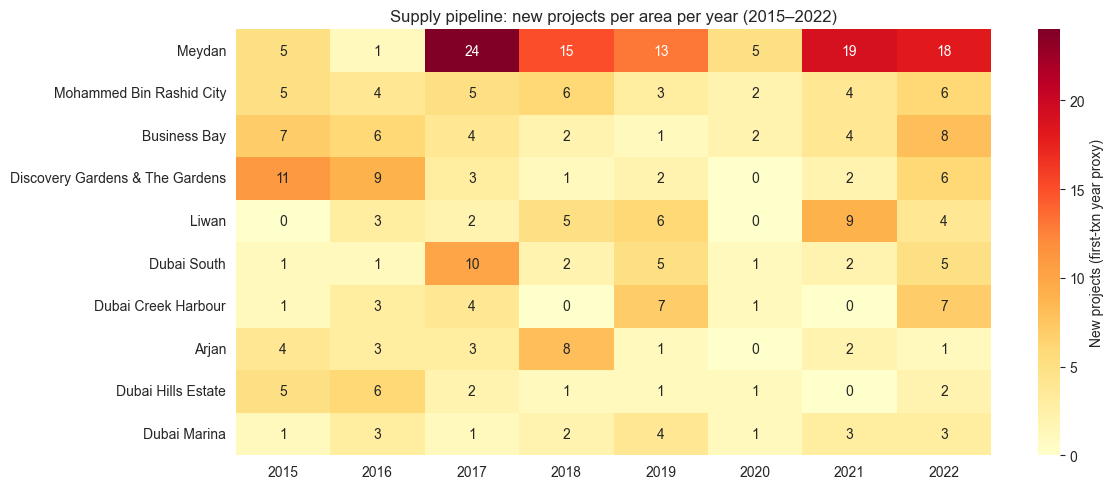

In [6]:
with db.connect() as conn:
    pipe = pd.read_sql(
        """SELECT COALESCE(a.display_name, a.area_name) AS area,
                  s.handover_year_proxy AS year, s.new_projects
           FROM v_supply_pipeline_proxy s JOIN areas a ON a.area_id = s.area_id
           WHERE s.handover_year_proxy BETWEEN 2015 AND 2022""",
        conn,
    )
top_supply = pipe.groupby('area')['new_projects'].sum().sort_values(ascending=False).head(10).index
pipe_top = pipe[pipe['area'].isin(top_supply)]

pivot = pipe_top.pivot(index='area', columns='year', values='new_projects').fillna(0)
pivot = pivot.loc[top_supply]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax,
            cbar_kws={'label': 'New projects (first-txn year proxy)'})
ax.set_title('Supply pipeline: new projects per area per year (2015–2022)')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

## 6. Week 2 candidate findings — preliminary log

Ranked by recruiter-relevance for the Week 3 Medium article:

1. **Business Bay off-plan inversion**: off-plan trades systematically *above* ready by ~30–60%, defying the conventional discount story. Drives a hypothesis about how Burj-area premium launches reshape the ready-market reference price.
2. **Meydan supply concentration**: 19+18 new projects in 2021–22 — Dubai's most concentrated supply pipeline. Sets up a follow-up about whether absorption can keep up.
3. **Cycle-stratified YoY heatmap**: areas like Marsa Dubai / Burj Khalifa show the cleanest macro-driven cycles, while International City / Discovery Gardens decouple. Useful for an 'investor vs end-user' market segmentation argument.
4. **Off-plan share as sentiment gauge**: monthly off-plan share traces the 2009 collapse, 2018–19 cooling, 2021–22 boom in a single chart. Good for the Macro Trends dashboard view.

Week 3 will dive into one or two of these with full data + a polished chart per finding.